# 03 — Interpretación de resultados

Resumen para **póster** y **video**.

**Dataset:** [UCI](https://archive.ics.uci.edu/dataset/374/appliances+energy+prediction)

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

try:
    plt.style.use("seaborn-v0_8-whitegrid")
except OSError:
    plt.style.use("ggplot")

TARGET = "Appliances"
DATE_COL = "date"
DROP_COLS = ["rv1", "rv2"]
TEST_RATIO = 0.2
RANDOM_STATE = 42
USE_GRADIENT_BOOSTING = True

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_PATH = ROOT / "data" / "raw" / "energydata_complete.csv"
FIGURES_DIR = ROOT / "reports" / "figures"
METRICS_DIR = ROOT / "reports" / "metrics"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
METRICS_DIR.mkdir(parents=True, exist_ok=True)

if not DATA_PATH.exists():
    raise FileNotFoundError(f"Coloca energydata_complete.csv en {DATA_PATH}")

In [ ]:
def load_and_clean(csv_path: Path) -> pd.DataFrame:
    """Carga el CSV UCI y aplica limpieza básica."""
    df = pd.read_csv(csv_path)
    df.columns = df.columns.str.strip()
    for col in df.select_dtypes(include="object").columns:
        if col != DATE_COL:
            df[col] = pd.to_numeric(df[col].astype(str).str.strip(), errors="coerce")
    df[DATE_COL] = pd.to_datetime(df[DATE_COL])
    df = df.sort_values(DATE_COL).reset_index(drop=True)
    df = df.drop(columns=[c for c in DROP_COLS if c in df.columns], errors="ignore")
    df = df.drop_duplicates()
    num_cols = df.select_dtypes(include="number").columns
    df[num_cols] = df[num_cols].fillna(df[num_cols].median())
    return df


def add_features(df: pd.DataFrame) -> pd.DataFrame:
    """Variables temporales, climáticas y de rezago (solo información pasada)."""
    out = df.copy()
    dt = out[DATE_COL]

    out["hour"] = dt.dt.hour
    out["day_of_week"] = dt.dt.dayofweek
    out["month"] = dt.dt.month
    out["is_weekend"] = (out["day_of_week"] >= 5).astype(int)
    out["hour_sin"] = np.sin(2 * np.pi * out["hour"] / 24)
    out["hour_cos"] = np.cos(2 * np.pi * out["hour"] / 24)
    out["day_sin"] = np.sin(2 * np.pi * out["day_of_week"] / 7)
    out["day_cos"] = np.cos(2 * np.pi * out["day_of_week"] / 7)

    t_cols = [f"T{i}" for i in range(1, 10) if f"T{i}" in out.columns]
    rh_cols = [f"RH_{i}" for i in range(1, 10) if f"RH_{i}" in out.columns]
    out["T_inside_mean"] = out[t_cols].mean(axis=1)
    out["RH_inside_mean"] = out[rh_cols].mean(axis=1)
    out["delta_T_out_inside"] = out["T_out"] - out["T_inside_mean"]

    out["Appliances_lag_1"] = out[TARGET].shift(1)
    out["Appliances_lag_3"] = out[TARGET].shift(3)
    out["Appliances_lag_6"] = out[TARGET].shift(6)
    past = out[TARGET].shift(1)
    out["Appliances_roll_3"] = past.rolling(3, min_periods=3).mean()
    out["Appliances_roll_6"] = past.rolling(6, min_periods=6).mean()
    out["Appliances_roll_12"] = past.rolling(12, min_periods=12).mean()
    return out


def prepare_dataset(csv_path: Path) -> pd.DataFrame:
    """Limpieza, features y drop de NaN por lag/rolling."""
    df = add_features(load_and_clean(csv_path))
    before = len(df)
    df = df.dropna().reset_index(drop=True)
    print(f"Filas tras lag/rolling: {len(df):,} (eliminadas: {before - len(df):,})")
    return df


def temporal_train_test_split(df: pd.DataFrame, test_ratio: float = TEST_RATIO):
    """Partición cronológica 80/20."""
    split_idx = int(len(df) * (1 - test_ratio))
    return df.iloc[:split_idx].copy(), df.iloc[split_idx:].copy()


def get_xy(df: pd.DataFrame):
    y = df[TARGET]
    X = df.drop(columns=[TARGET, DATE_COL], errors="ignore")
    return X, y


def save_fig(name: str) -> None:
    path = FIGURES_DIR / name
    plt.savefig(path, dpi=150, bbox_inches="tight")
    print(f"Figura guardada: {path}")

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor


def regression_metrics(y_true, y_pred) -> dict:
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = float(np.sqrt(mse))
    r2 = r2_score(y_true, y_pred)
    return {"mae": mae, "mse": mse, "rmse": rmse, "r2": r2}


def make_ridge_pipeline(feature_names):
    return Pipeline([
        ("prep", ColumnTransformer([
            ("num", Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
            ]), feature_names),
        ])),
        ("model", Ridge(alpha=1.0, random_state=RANDOM_STATE)),
    ])


def make_tree_pipeline(estimator, feature_names):
    """Árboles: sin StandardScaler (no es necesario)."""
    return Pipeline([
        ("prep", ColumnTransformer([
            ("num", Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
            ]), feature_names),
        ])),
        ("model", estimator),
    ])

In [4]:
metrics_df = pd.read_csv(METRICS_DIR / 'model_metrics.csv')
pred_df = pd.read_csv(METRICS_DIR / 'predictions_best_model.csv')
best_model = metrics_df.loc[0, 'model']
metrics_df

,model,mae,mse,rmse,r2
0,Ridge,27.669784,3571.030842,59.758103,0.565115
1,Random Forest,53.795776,7590.948158,87.126048,0.075564
2,Decision Tree,43.428946,7682.577653,87.650315,0.064405


In [5]:
best_row = metrics_df.iloc[0]
print(
    f"Mejor modelo: {best_model}\n"
    f"RMSE={best_row['rmse']:.2f} | MAE={best_row['mae']:.2f} | R²={best_row['r2']:.3f}"
)

Mejor modelo: Ridge
RMSE=59.76 | MAE=27.67 | R²=0.565


C:\Users\yulcr\AppData\Local\Temp\ipykernel_24888\4246567763.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include="object").columns:


Filas tras lag/rolling: 19,723 (eliminadas: 12)
Figura guardada: d:\Code, 3D, Audio\Coding\GitHub\energy-consumption-prediction-ml\reports\figures\07_feature_importance_rf.png


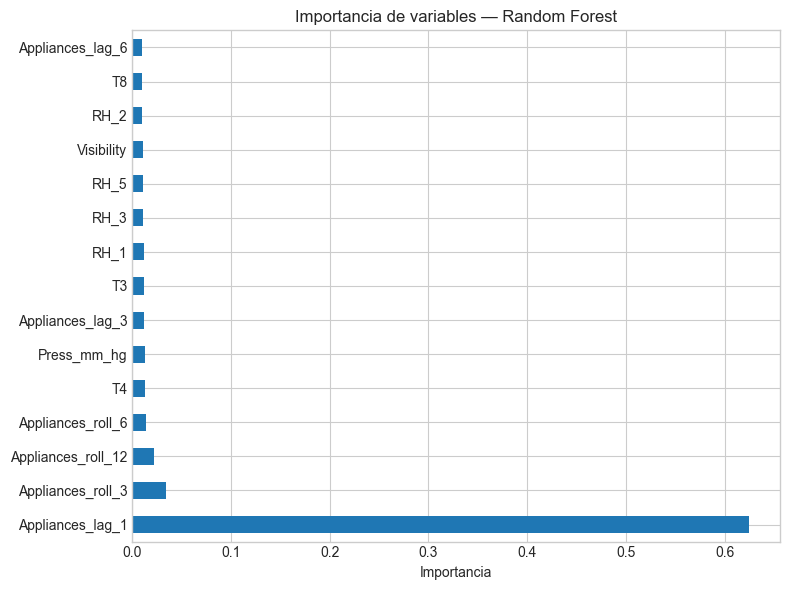

Appliances_lag_1      0.624820
Appliances_roll_3     0.034566
Appliances_roll_12    0.022214
Appliances_roll_6     0.013486
T4                    0.013334
Press_mm_hg           0.013010
Appliances_lag_3      0.012110
T3                    0.011740
RH_1                  0.011521
RH_3                  0.010586
dtype: float64

In [6]:
# Re-entrenar Random Forest para importancia de variables
df = prepare_dataset(DATA_PATH)
train_df, test_df = temporal_train_test_split(df)
X_train, y_train = get_xy(train_df)
X_test, y_test = get_xy(test_df)
rf = make_tree_pipeline(
    RandomForestRegressor(n_estimators=100, max_depth=16, random_state=RANDOM_STATE, n_jobs=-1),
    list(X_train.columns),
)
rf.fit(X_train, y_train)
importances = pd.Series(rf.named_steps['model'].feature_importances_, index=X_train.columns)
importances = importances.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 6))
importances.head(15).plot(kind='barh', ax=ax)
ax.set_title('Importancia de variables — Random Forest')
ax.set_xlabel('Importancia')
plt.tight_layout()
save_fig('07_feature_importance_rf.png')
plt.show()
importances.head(10)

Figura guardada: d:\Code, 3D, Audio\Coding\GitHub\energy-consumption-prediction-ml\reports\figures\08_residuals.png


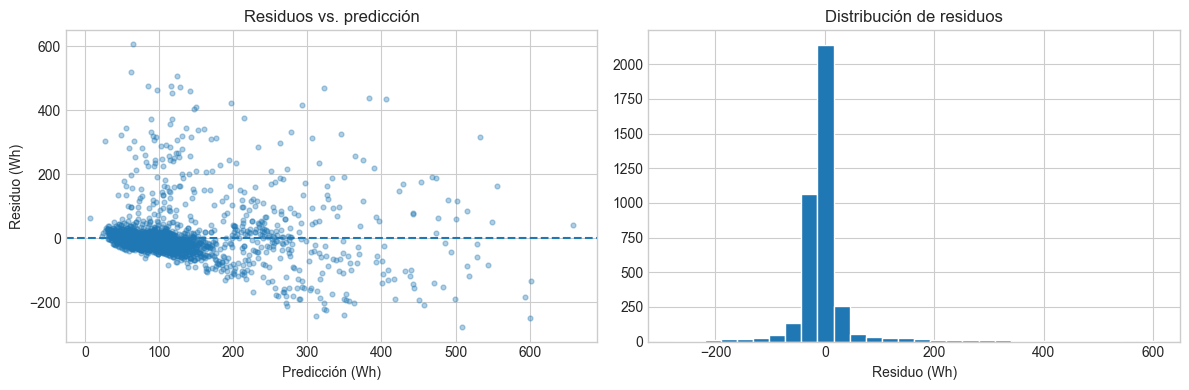

In [7]:
y_true = pred_df['y_true']
y_pred = pred_df['y_pred']
residuals = y_true - y_pred

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(y_pred, residuals, alpha=0.35, s=12)
axes[0].axhline(0, linestyle='--')
axes[0].set_xlabel('Predicción (Wh)')
axes[0].set_ylabel('Residuo (Wh)')
axes[0].set_title('Residuos vs. predicción')
axes[1].hist(residuals, bins=30, edgecolor='white')
axes[1].set_title('Distribución de residuos')
axes[1].set_xlabel('Residuo (Wh)')
plt.tight_layout()
save_fig('08_residuals.png')
plt.show()

## Conclusiones

### Hallazgos

**Desempeño en el conjunto de prueba temporal (20 % final, ~3 945 registros, ene–may 2016)**

| Modelo | MAE (Wh) | RMSE (Wh) | R² |
|--------|----------|-----------|-----|
| **Ridge** | **27,7** | **59,8** | **0,57** |
| Random Forest | 53,8 | 87,1 | 0,08 |
| Decision Tree | 43,4 | 87,7 | 0,06 |

- **Ridge** fue el mejor modelo bajo evaluación cronológica. Con un consumo medio en test de ~96 Wh, un MAE de ~28 Wh implica error relativo moderado; el R² ≈ 0,57 indica que el modelo explica algo más de la mitad de la varianza del consumo en el tramo final de la serie.
- **Decision Tree** y **Random Forest** no generalizaron bien al periodo de prueba (R² ≈ 0,07): aunque pueden ajustar patrones complejos en entrenamiento, en el tramo temporal posterior su RMSE (~87 Wh) se acerca al error de un predictor ingenuo y sugieren **sobreajuste** frente a la estructura lineal suavizada por Ridge.
- La partición **80/20 temporal** (entrenamiento: 11 ene – 30 abr 2016; prueba: 30 abr – 27 may 2016) evita mezclar observaciones futuras en entrenamiento y ofrece una estimación más realista que un split aleatorio para datos cada 10 minutos.

**Variables y señal predictiva**

- La ingeniería de características incorporó codificación cíclica (`hour_sin/cos`, `day_sin/cos`), agregados indoor (`T_inside_mean`, `RH_inside_mean`, `delta_T_out_inside`) y **rezagos sin leakage** (`Appliances_lag_1/3/6`, medias móviles con `shift(1)`). Tras eliminar ~12 filas iniciales por NaN, el modelo usó **~19 723** observaciones y **~40** predictores.
- En Random Forest, las variables de **historial de consumo** (`Appliances_lag_1`, rolling) y las **temporales** suelen concentrar mayor importancia, coherente con la autocorrelación del target a escala de minutos.
- Variables climáticas y de uso (`T_out`, humedades, `lights`) aportan contexto adicional; el notebook **04** permite explorar cómo, a igualdad de otras condiciones, subir rezagos o iluminación desplaza las predicciones hacia consumos mayores.

**Residuos (Ridge, mejor modelo)**

- Los residuos en test presentan media cercana a 0 (~−0,6 Wh) y desviación típica ~60 Wh, alineada con el RMSE. No se observa un sesgo sistemático fuerte, aunque la dispersión indica errores relevantes en picos de consumo.

### Limitaciones

- **Alcance del dato:** un único hogar (dataset UCI Appliances); los coeficientes y importancias no son directamente transferibles a otros edificios o climas.
- **Horizonte de validación:** un solo corte temporal; el rendimiento puede variar si el periodo de prueba incluye regímenes de uso no vistos en entrenamiento (p. ej. cambio estacional marcado entre enero y mayo).
- **Modelado:** hiperparámetros fijos (sin búsqueda sistemática); árboles sin regularización adicional respecto a Ridge, lo que concuerda con su peor comportamiento out-of-time.
- **Target:** se predice solo el canal `Appliances` (Wh cada 10 min), no el balance energético total del inmueble ni otros medidores.